Подключаем нужные библиотеки

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # устанавливаем seaborn по умолчанию для отрисовки графиков

Даем доступ к диску

In [199]:
from google.colab import drive

drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Читаем файл + перевод из дней в года для возраста

In [200]:
train = pd.read_csv('/content/drive/MyDrive/Labs_ai/Lab_1/cirrhosis.csv')
train['Age_years'] = (train['Age'] / 365.25).round(1)

Вывод первых позиций

In [201]:
train.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_years
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,...,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,58.8
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,...,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,56.4
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,...,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,70.1
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,...,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,54.7
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,...,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,38.1


https://archive.ics.uci.edu/dataset/878/cirrhosis+patient+survival+prediction+dataset-1
1. ID: уникальный идентификатор.
2. N_Days: количество дней между регистрацией и датой смерти, трансплантации или анализа исследования в июле 1986 года.
3. Статус: состояние пациента C (цензурировано), CL (цензурировано из-за поражения печени) или D (смерть)
4. Лекарство: тип препарата D-пеницилламин или плацебо
5. Возраст: возраст в [днях]
6. Пол: M (мужчина) или F (женщина)
7. Асцит: наличие асцита N (Нет) или Y (Да)
8. Гепатомегалия: наличие гепатомегалии N (Нет) или Y (Да)
9. Пауки: наличие пауков N (Нет) или Y (Да)
10. Отек: наличие отека N (отсутствие отека и отсутствие диуретической терапии отека), S (отек присутствует без диуретиков или отек устраняется диуретиками) или Y (отек, несмотря на диуретическую терапию)
11. Билирубин: билирубин в сыворотке крови в [мг/дл]
12. Холестерин: холестерин в сыворотке крови в [мг/дл]
13. Альбумин: альбумин в [г / дл]
14. Медь: медь в моче в [мкг / день]
15. Alk_Phos: щелочная фосфатаза в [Ед / л]
16. SGOT: SGOT в [Ед / мл]
17. Триглицериды: триглицериды в [мг / дл]
18. Тромбоциты: количество тромбоцитов на кубический объем [мл / 1000]
19. Протромбин: протромбиновое время в секундах [с]
20. Стадия: гистологическая стадия заболевания (1, 2, 3 или 4)

Получаем статистику для всех числовых столбцов

In [202]:
train.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_years
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000,418.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272,50.744019
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042,10.445328
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000,26.300000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000,42.850000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000,51.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000,58.275000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000,78.400000


Из представленных данных в нашем файле:

1. содержится 418 строк
2. диапазон ID от 1 до 418,
показаны среднее, стандартное отклонение от среднего,
квантили разной вероятности

Анализ нечисловых данных

In [203]:
train.describe(include=['O'])

,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema
count,418,312,418,312,312,312,418
unique,3,2,2,2,2,2,3
top,C,D-penicillamine,F,N,Y,N,N
freq,232,158,374,288,160,222,354


1. всего записей 418
2. уникальные записи от 2х до 3х
3. на примере статуса чаще всего встречается C c частотой 232


Информация о полях

In [204]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

Проверка на пропуски

In [205]:
train.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0


Пропуски есть в столбцах
Drug,
Hepatomegaly,
Spiders, Cholesterol,
Copper,
Alk_Phos,
SGOT,
Tryglicerides,
Platelets,
Prothrombin,
Stage

Определим тип столбца

In [206]:
for column in train.columns:
    if train[column].dtype in ['int64', 'float64']:
        print(f"{column}: количественный")
    else:
        unique_values = train[column].nunique()
        if unique_values == 2:
            print(f"{column}: бинарный")
        else:
            print(f"{column}: категориальный ({unique_values} уникальных значений)")

ID: количественный
N_Days: количественный
Status: категориальный (3 уникальных значений)
Drug: бинарный
Age: количественный
Sex: бинарный
Ascites: бинарный
Hepatomegaly: бинарный
Spiders: бинарный
Edema: категориальный (3 уникальных значений)
Bilirubin: количественный
Cholesterol: количественный
Albumin: количественный
Copper: количественный
Alk_Phos: количественный
SGOT: количественный
Tryglicerides: количественный
Platelets: количественный
Prothrombin: количественный
Stage: количественный
Age_years: количественный


Заполнение пропусков

In [207]:
# Для числовых признаков - заполнение средним или медианой
# Бинарные просто удаляем. Грубо, зато все чисто))
train.Cholesterol = train.Cholesterol.fillna(train.Cholesterol.median())
train.Copper = train.Copper.fillna(train.Copper.median())
train.Tryglicerides = train.Tryglicerides.fillna(train.Tryglicerides.median())
train.Platelets = train.Platelets.fillna(train.Platelets.median())
train.Prothrombin = train.Prothrombin.fillna(train.Prothrombin.median())
train.Stage = train.Stage.fillna(train.Stage.median())
train.Alk_Phos = train.Alk_Phos.fillna(train.Alk_Phos.median())
train.SGOT= train.SGOT.fillna(train.SGOT.median())
train.drop(columns=['Drug'], inplace=True)
train.drop(columns=['Hepatomegaly'], inplace=True)
train.drop(columns=['Spiders'], inplace=True)
train.drop(columns=['Ascites'], inplace=True)
train.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Age,0
Sex,0
Edema,0
Bilirubin,0
Cholesterol,0
Albumin,0
Copper,0


Визуализация распределений и взаимосвязей

In [208]:
print(train.columns.tolist())

['ID', 'N_Days', 'Status', 'Age', 'Sex', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Age_years']


Построим гистограмму, демонстрирующую статус и стадию пациента в этом наборе данных.

(array([161.,   0.,   0.,   0.,   0., 232.,   0.,   0.,   0.,  25.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

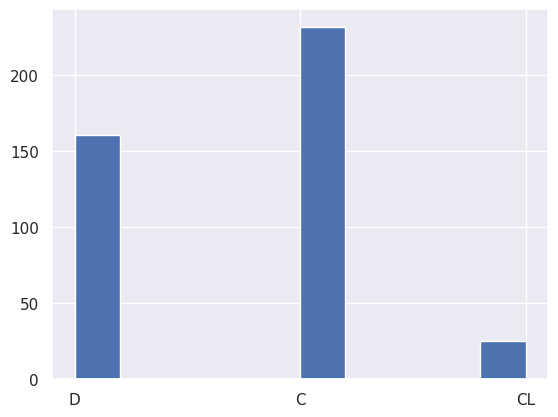

In [209]:
plt.hist(train['Status'])

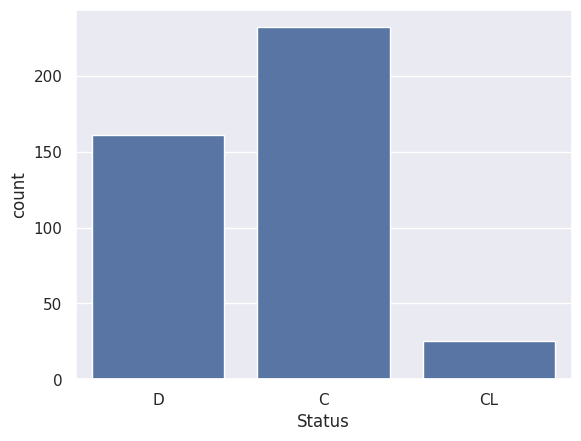

In [210]:
sns.countplot(x=train["Status"]);


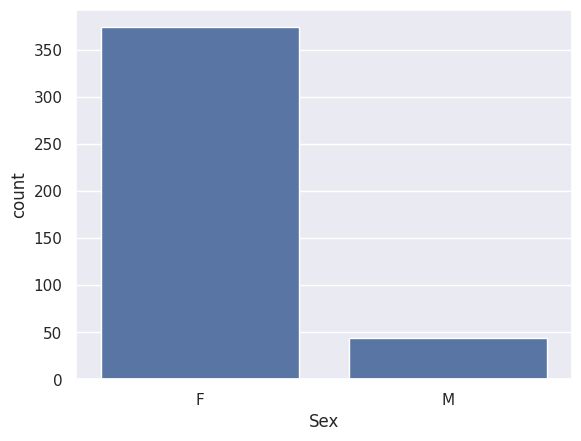

In [211]:
sns.countplot(x=train["Sex"]);

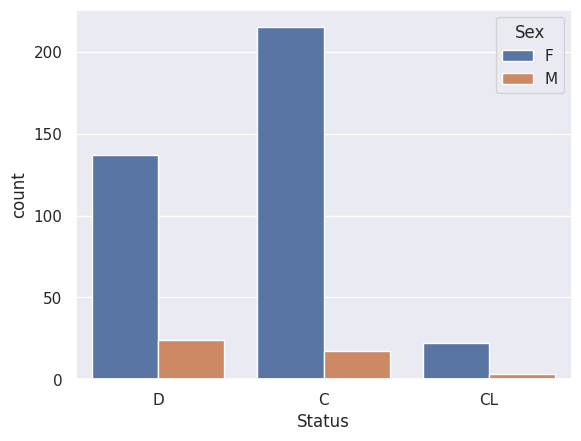

In [212]:
sns.countplot(data=train, x="Status", hue='Sex');

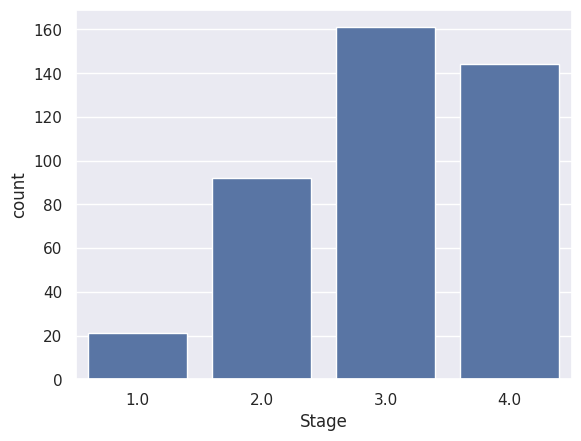

In [213]:
sns.countplot(x=train["Stage"]);

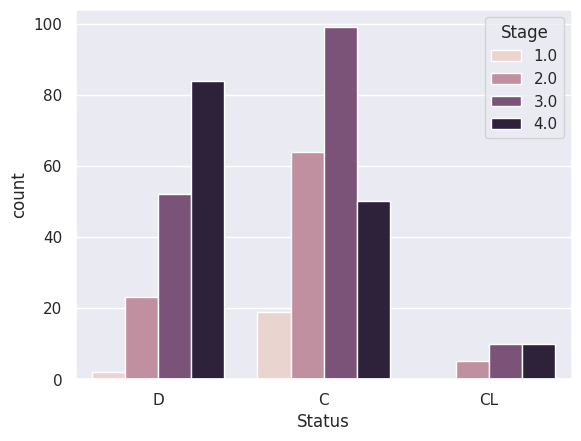

In [214]:
sns.countplot(data=train, x="Status", hue='Stage');

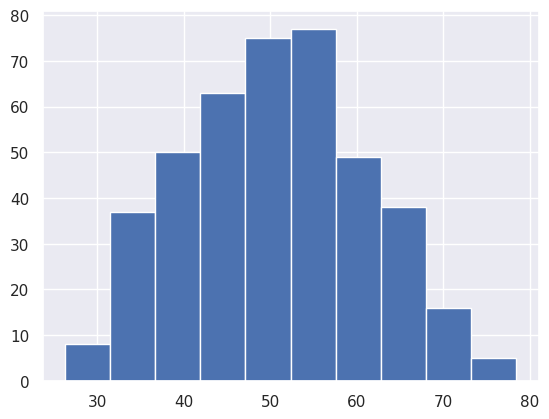

In [215]:
train.Age_years.hist();

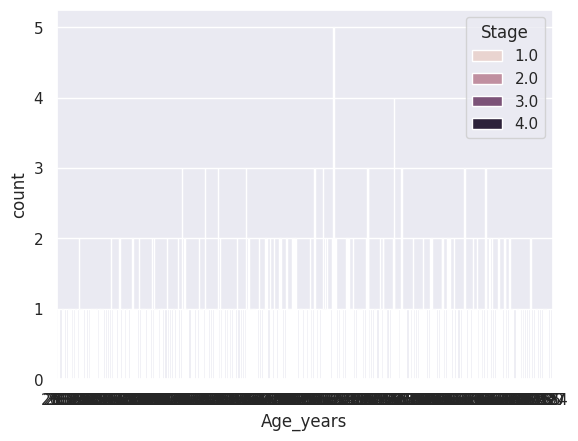

In [236]:
sns.countplot(data=train, x="Age_years", hue='Stage');

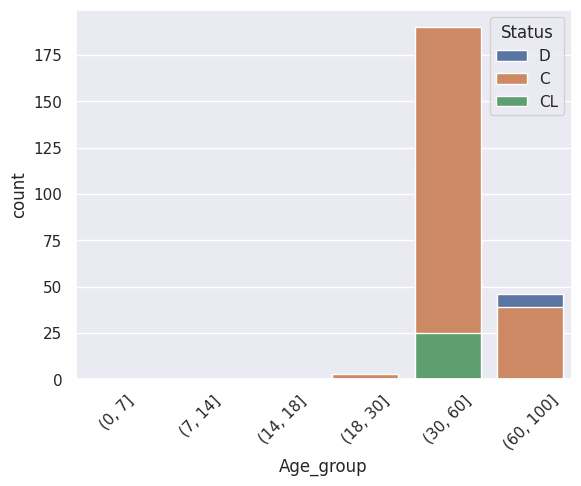

In [217]:
train["Age_group"] = pd.cut(x=train['Age_years'], bins=[0, 7, 14, 18, 30, 60, 100])
plt.xticks(rotation=45)
sns.countplot(data=train, hue='Status', x='Age_group');

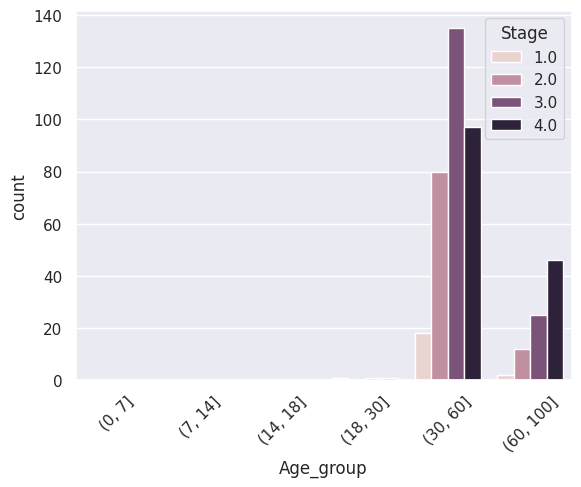

In [237]:
train["Age_group"] = pd.cut(x=train['Age_years'], bins=[0, 7, 14, 18, 30, 60, 100])
plt.xticks(rotation=45)
sns.countplot(data=train, hue='Stage', x='Age_group');

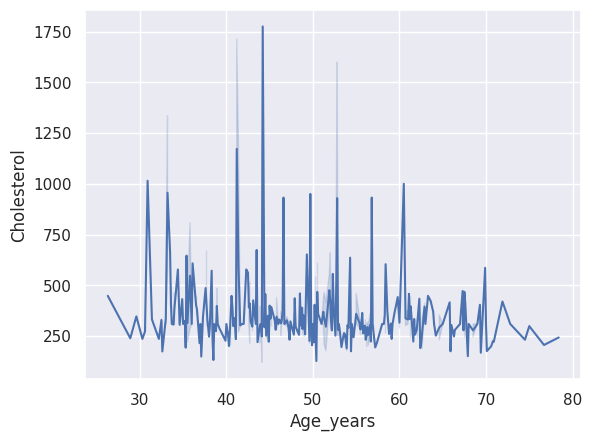

In [218]:
sns.lineplot(data=train, x='Age_years', y='Cholesterol');

In [219]:
sns.pairplot(train, kind="scatter", hue="Status");

Output hidden; open in https://colab.research.google.com to view.

In [238]:
sns.pairplot(train, kind="scatter", hue="Stage");

Output hidden; open in https://colab.research.google.com to view.

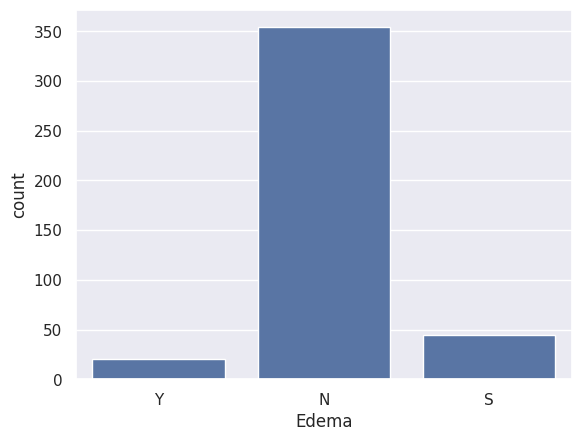

In [229]:
sns.countplot(x=train["Edema"]);

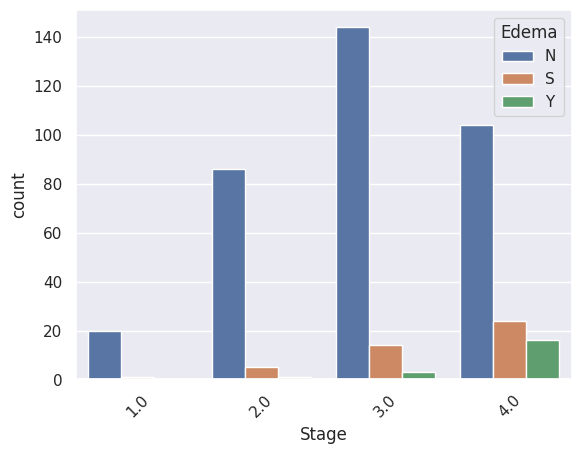

In [235]:
train["Stage_group"] = pd.cut(x=train['Stage'], bins=[0, 4])
plt.xticks(rotation=45)
sns.countplot(data=train, hue='Edema', x='Stage');

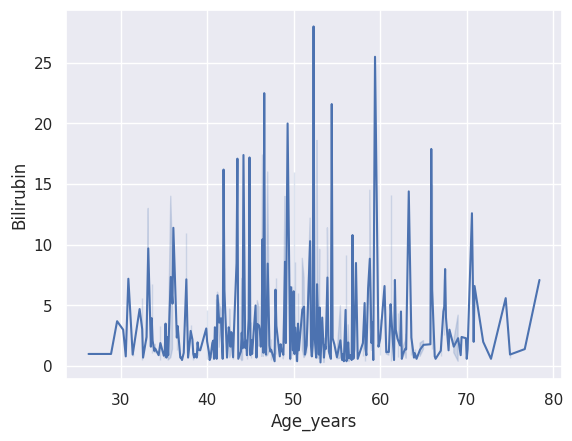

In [228]:
sns.lineplot(data=train, x='Age_years', y='Bilirubin');

Преобразование категориального признака в количественный

In [222]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
train[['Status']] = enc.fit_transform(train[['Status']])
train.head()

,ID,N_Days,Status,Age,Sex,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_years,Age_group
0,1,400,2.0,21464,F,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,58.8,"(30, 60]"
1,2,4500,0.0,20617,F,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,56.4,"(30, 60]"
2,3,1012,2.0,25594,M,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,70.1,"(60, 100]"
3,4,1925,2.0,19994,F,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,54.7,"(30, 60]"
4,5,1504,1.0,13918,F,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,38.1,"(30, 60]"


In [224]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   ID             418 non-null    int64   
 1   N_Days         418 non-null    int64   
 2   Status         418 non-null    float64 
 3   Age            418 non-null    int64   
 4   Sex            418 non-null    object  
 5   Edema          418 non-null    object  
 6   Bilirubin      418 non-null    float64 
 7   Cholesterol    418 non-null    float64 
 8   Albumin        418 non-null    float64 
 9   Copper         418 non-null    float64 
 10  Alk_Phos       418 non-null    float64 
 11  SGOT           418 non-null    float64 
 12  Tryglicerides  418 non-null    float64 
 13  Platelets      418 non-null    float64 
 14  Prothrombin    418 non-null    float64 
 15  Stage          418 non-null    float64 
 16  Age_years      418 non-null    float64 
 17  Age_group      418 non-null    cate

Был object стал float64